# Full-sample SVAR, 1974–2025

Thin interactive wrapper over `src/oil_models`. See `docs/` for the methodology and `reports/RESULTS.md` for the full generated results.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from oil_models import data_prep, hormuz, kilian_var as kv, scenarios, evaluate, benchmarks, regression, combine, volatility, external_data

In [2]:
full = data_prep.load_kilian_dataset()
m = kv.fit(full[data_prep.VAR_COLUMNS])
kv.stable(m)

(True, 0.9856297855177316)

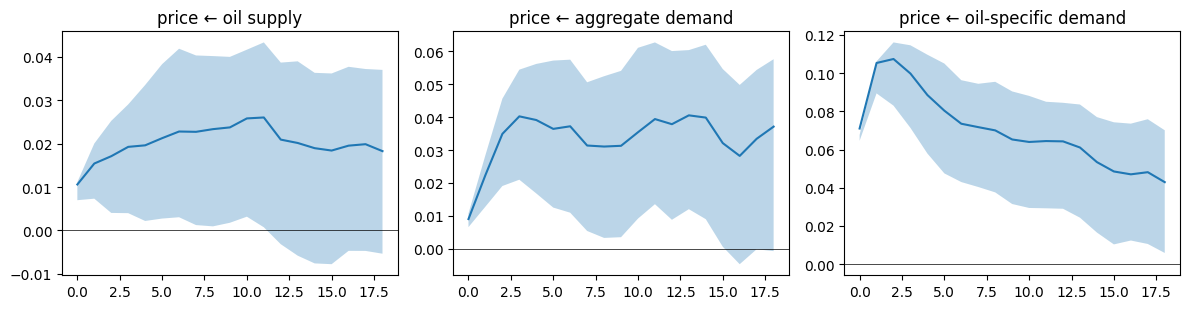

In [3]:
lo, hi = kv.bootstrap_irf(m, 18, reps=200)  # bump reps for final figures
theta = kv.irf(m, 18)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for s_ in range(3):
    axes[s_].fill_between(range(19), lo[:,2,s_], hi[:,2,s_], alpha=.3)
    axes[s_].plot(theta[:,2,s_]); axes[s_].axhline(0, c='k', lw=.5)
    axes[s_].set_title(f'price ← {kv.SHOCK_NAMES[s_]}')
plt.tight_layout()

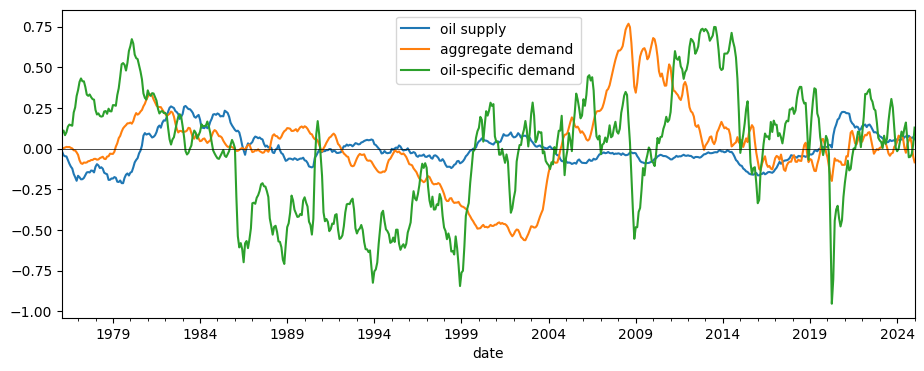

In [4]:
hd = kv.historical_decomposition(m)['ln_real_oil_price']
hd[kv.SHOCK_NAMES].plot(figsize=(11,4)); plt.axhline(0, c='k', lw=.5);